<a href="https://colab.research.google.com/github/FadhilSF/Portofolio/blob/main/Portofolio_Time_Series_Analysis_BBCA_Shares_with_LSTM_Algorithm_and_Bayesian_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INSTALL LIBRARY

In [1]:
!pip install tensorflow
!pip install keras-tuner

# IMPORTING LIBRARIES

In [2]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import gdown
plt.style.use('fivethirtyeight')

# IMPORT DATASET FROM GOOGLE DRIVE AS CSV FILE

In [3]:
url = "https://drive.google.com/file/d/1-ZeuBCCDlb9Xx5Vfkovrr272xIPw43c-/view?usp=sharing"
output = "Data_BBCA.csv"
gdown.download(url, output, quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1-ZeuBCCDlb9Xx5Vfkovrr272xIPw43c-
To: /content/Data_BBCA.csv
100%|██████████| 617k/617k [00:00<00:00, 104MB/s]


'Data_BBCA.csv'

In [4]:
saham = pd.read_csv('/content/Data_BBCA.csv')
saham

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2004-06-08 00:00:00+07:00,93.551091,96.223979,93.551091,94.887535,499150000,0.0,0.0
1,2004-06-09 00:00:00+07:00,94.887509,97.560397,93.551066,96.223953,294290000,0.0,0.0
2,2004-06-10 00:00:00+07:00,96.223953,96.223953,94.887509,96.223953,165590000,0.0,0.0
3,2004-06-11 00:00:00+07:00,94.887509,96.223953,94.887509,96.223953,135830000,0.0,0.0
4,2004-06-14 00:00:00+07:00,96.223979,96.223979,93.551091,94.887535,158540000,0.0,0.0
...,...,...,...,...,...,...,...,...
5389,2026-04-20 00:00:00+07:00,6450.000000,6575.000000,6425.000000,6475.000000,137435700,0.0,0.0
5390,2026-04-21 00:00:00+07:00,6475.000000,6525.000000,6425.000000,6500.000000,112151900,0.0,0.0
5391,2026-04-22 00:00:00+07:00,6475.000000,6525.000000,6450.000000,6450.000000,95673700,0.0,0.0
5392,2026-04-23 00:00:00+07:00,6450.000000,6550.000000,6425.000000,6425.000000,95913400,0.0,0.0


# DATA OVERVIEW

In [5]:
saham.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5394 entries, 0 to 5393
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5394 non-null   object 
 1   Open          5394 non-null   float64
 2   High          5394 non-null   float64
 3   Low           5394 non-null   float64
 4   Close         5394 non-null   float64
 5   Volume        5394 non-null   int64  
 6   Dividends     5394 non-null   float64
 7   Stock Splits  5394 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 337.3+ KB


# Data Cleaning

## CHECK FOR MISSING AND DUPLICATE VALUE


In [6]:
# Check for Null/Missing Value
saham.isnull().sum()


,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0


In [7]:
# Check for Duplicated Value
saham.duplicated().sum()

np.int64(0)

# PREPROCESSING

## FORMATTING DATASET

In [8]:
#In this time series analysis we only need "Date" and "Close" Data

#change the "date" data into datetime format so that it can be read by the model
saham['Date'] = pd.to_datetime(saham['Date'])
saham.set_index('Date', inplace=True)

#Select the "Close" column to be analyzed by the model
data = saham.filter(['Close'])
dataset = data.values

In [9]:
dataset

array([[  94.8875351 ],
       [  96.22395325],
       [  96.22395325],
       ...,
       [6450.        ],
       [6425.        ],
       [6050.        ]])

## SPLIT DATA INTO DATA TRAIN (80%) AND DATA TEST (20%)

In [10]:
training_data_len = math.ceil(len(dataset) * 0.8)
test_data_len = len(dataset) - training_data_len

train_data_raw = dataset[0:training_data_len, :]
test_data_raw = dataset[training_data_len:, :]

print(f"--- Data Sharing Details ---")
print(f"Total rows of dataframe : {len(dataset)}")
print(f"Amount of Training data : {len(train_data_raw)}")
print(f"Amount of Testing data  : {len(test_data_raw)}")
print("-" * 30)

--- Data Sharing Details ---
Total rows of dataframe : 5394
Amount of Training data : 4316
Amount of Testing data  : 1078
------------------------------


## Normalization and Sequence Generation

In [11]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit & Transform train set
train_scaled = scaler.fit_transform(train_data_raw)

# Transform data Test
test_scaled = scaler.transform(test_data_raw)

# Time Window
window_size = 60
x_train, y_train = [], []

for i in range(window_size, len(train_scaled)):
    x_train.append(train_scaled[i-window_size:i, 0])
    y_train.append(train_scaled[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f"Input structure x_train: {x_train.shape}")

Input structure x_train: (4256, 60, 1)


# MODELLING

## LONG SHORT-TERM MEMORY

In [12]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(x_train.shape[1], 1)))

    # Tuning the Number of LSTM Units
    hp_units = hp.Int('units', min_value=50, max_value=250, step=50)
    model.add(LSTM(units=hp_units, return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(0.001)))

    # Tuning Dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.4, step=0.2)
    model.add(Dropout(hp_dropout))

    model.add(LSTM(units=hp_units // 2, return_sequences=False, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(Dropout(hp_dropout))

    # Additional Dense Layer
    model.add(Dense(units=hp.Int('dense_units', 16, 64, step=16), activation='relu'))
    model.add(Dense(units=1))

    # Tuning Learning Rate
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 5e-3, 1e-3, 5e-4, 1e-4])

    model.compile(optimizer=Adam(learning_rate=hp_lr), loss='mean_squared_error')
    return model

## HYPERTUNING BAYESIAN OPTIMIZATION

In [13]:
# Initializing the Bayesian Optimization Tuner
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=10,
    directory='tuning_BBCA_final',
    project_name='lstm_BBCA'
)

# Callback Early Stopping
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Best Parameter Search Process
print("\n--- Memulai Hyperparameter Tuning ---")
tuner.search(x_train, y_train, epochs=20, validation_split=0.2, callbacks=[stop_early])

# Take the best model of the tuning results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
model = tuner.hypermodel.build(best_hps)

Trial 10 Complete [00h 02m 10s]
val_loss: 0.002229708945378661

Best val_loss So Far: 0.0013216705992817879
Total elapsed time: 01h 10m 04s


# Final Model Training & Prediction

In [14]:
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2,
                    callbacks=[stop_early], verbose=1)

# Data Test Prediction (input test set last 60 days of train data)
past_60_days = train_scaled[-window_size:]
test_inputs = np.concatenate((past_60_days, test_scaled), axis=0)

x_test = []
for i in range(window_size, len(test_inputs)):
    x_test.append(test_inputs[i-window_size:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 317ms/step - loss: 0.0899 - val_loss: 0.0058
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 317ms/step - loss: 7.6410e-04 - val_loss: 0.0017
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - loss: 5.6179e-04 - val_loss: 0.0017
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 321ms/step - loss: 5.7991e-04 - val_loss: 0.0061
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 41s 318ms/step - loss: 4.4799e-04 - val_loss: 0.0016
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 40s 305ms/step - loss: 4.2350e-04 - val_loss: 0.0019
Epoch 8/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 328ms/step - loss: 3.9347e-04 - val_loss: 0.0016
Epoch 9/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - loss: 5.1335e-04 - val_loss: 0.0023
Epoch 10/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 328ms/step - loss: 3.8979e-04 - val_loss: 0.0019
Epoch 11/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 302ms/step - loss: 4.3941e-04 - 

# MODEL EVALUATION

In [15]:
y_test_actual = dataset[training_data_len:, :]

mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions)

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_actual, predictions)

print(f"\n--- MODEL EVALUATION RESULTS ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


--- MODEL EVALUATION RESULTS ---
Root Mean Squared Error (RMSE): 426.21
Mean Absolute Error (MAE): 338.64
Mean Squared Error (MSE): 181652.24
Mean Absolute Percentage Error (MAPE): 4.11%


# RESULTS VISUALIZATION



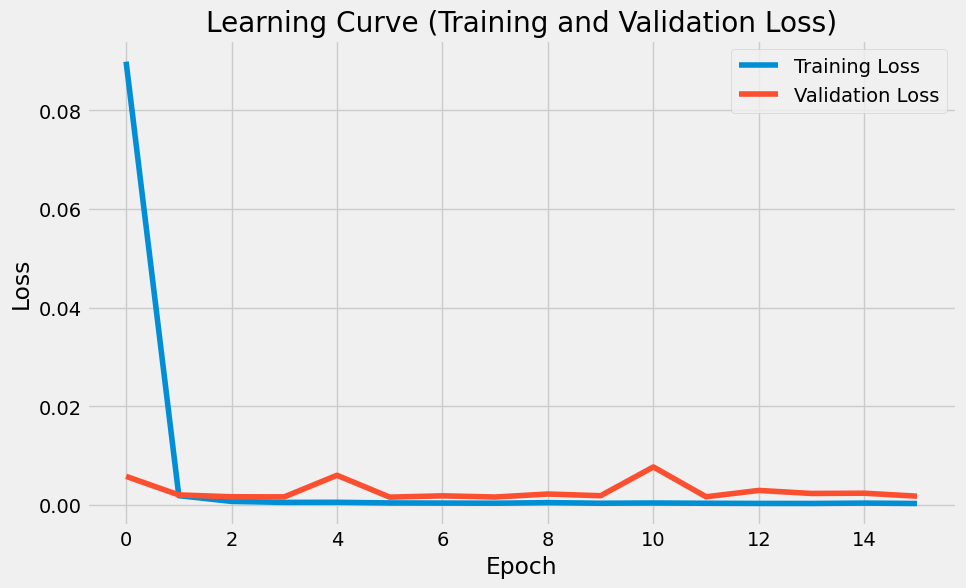

In [16]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(10, 6))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Learning Curve (Training and Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

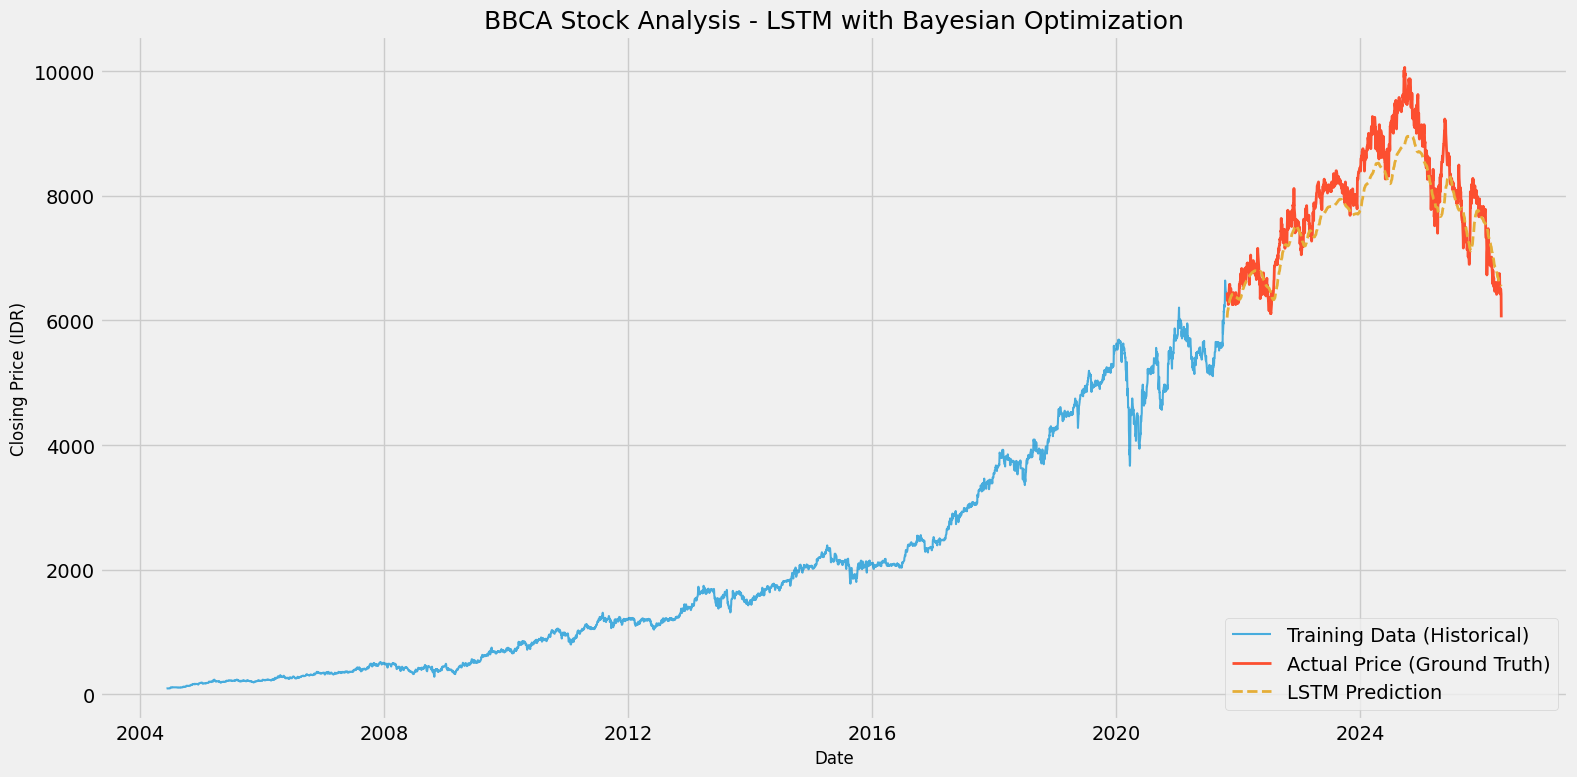

In [19]:
train = saham[:training_data_len]
valid = saham[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16, 8))
plt.title('BBCA Stock Analysis - LSTM with Bayesian Optimization', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (IDR)', fontsize=12)
plt.plot(train['Close'], label='Training Data (Historical)', linewidth=1.5, alpha=0.7)
plt.plot(valid['Close'], label='Actual Price (Ground Truth)', linewidth=2)
plt.plot(valid['Predictions'], label='LSTM Prediction', linewidth=2, linestyle='--')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()